    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6  Target
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0   151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0    75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0   141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0   206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0   135.0
              age         sex         bmi          bp          s1          s2  \
count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000   
mean    48.518100    1.468326   26.375792   94.647014  189.140271  115.439140   
std     13.109028    0.499561    4.418122   13.831283   34.608052   30.413081   
min     19.000000    1.000000   18.000000   62.000000   97.000000   41.600000   
25%     38.250000    1.000000   23.200000   84.000000  164.250000   96.050000   
50%     50.000000    1.000000   25.700000   93.000000  186.000000  113.00000

<Axes: >

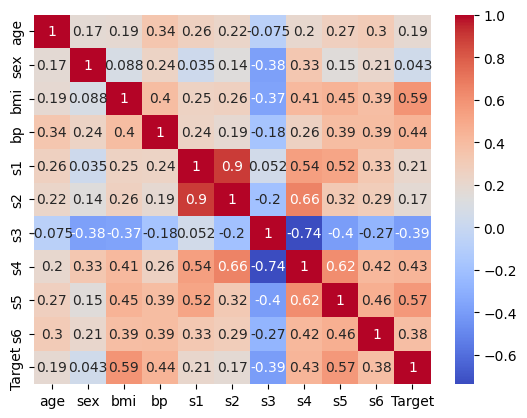

In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import seaborn as sns

df = pd.DataFrame(load_diabetes(scaled=False).data, columns=load_diabetes().feature_names)
df["Target"] = load_diabetes().target
print(df.head())
print(df.describe())

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Target"])
y = df["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

pipeSVR = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf', C=100, gamma=0.1))
])

pipeRF = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeSVR.fit(X_train, y_train)
pipeRF.fit(X_train, y_train)

print(f'SVR Score: {pipeSVR.score(X_test, y_test)}')
print(f'Random Forest Score: {pipeRF.score(X_test, y_test)}')

SVR Score: 0.5078392590548373
Random Forest Score: 0.44146927036843053


In [ ]:
from xgboost import XGBRegressor
import optuna 
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'learning_rate':      trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True), 
        'max_depth':          trial.suggest_int('max_depth', 1, 12), 
        'n_estimators':       trial.suggest_int('n_estimators', 700, 1600), 
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.5, 1.0),    
        'colsample_bynode':   trial.suggest_float('colsample_bynode', 0.5, 1.0), 
        'min_child_weight':   trial.suggest_int('min_child_weight', 2, 25), 
        'gamma':              trial.suggest_float('gamma', 0.0, 5.0), 
        'reg_alpha':          trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'tree_method': 'hist',
        'n_jobs': -1,
        'random_state': 42
    }

    model = XGBRegressor(**params)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500, show_progress_bar=True)

print(f"Miglior MSE (CV):    {-study.best_value:.4f}")
#print(f"Miglior R2 (CV):    {study.best_value:.4f}")
print(f"Migliori parametri: {study.best_params}")

/home/dave/git/CodeAcademy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 479. Best value: 0.45473: 100%|██████████| 500/500 [10:03<00:00,  1.21s/it] 

Miglior R2 (CV):    0.4547
Migliori parametri: {'learning_rate': 0.012242481162417294, 'max_depth': 1, 'n_estimators': 962, 'subsample': 0.5653789553515136, 'colsample_bytree': 0.9770101383954058, 'colsample_bylevel': 0.5127335917720693, 'colsample_bynode': 0.7872528616858241, 'min_child_weight': 10, 'gamma': 2.0991128523595455, 'reg_alpha': 0.23451680044446196, 'reg_lambda': 2.570368834514542}


In [5]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Addestra il modello finale con i parametri migliori
final_xgb = XGBRegressor(**study.best_params, random_state=42)
final_xgb.fit(X_train, y_train)

# Previsioni sul test set
y_pred = final_xgb.predict(X_test)

# Metriche finali
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}  ← errore medio in punti sulla scala target")
print(f"MAE:  {mae:.2f}  ← errore assoluto medio")
print(f"R²:   {r2:.2%} ← % di varianza spiegata")

MSE:  2699.33
RMSE: 51.96  ← errore medio in punti sulla scala target
MAE:  41.34  ← errore assoluto medio
R²:   49.05% ← % di varianza spiegata


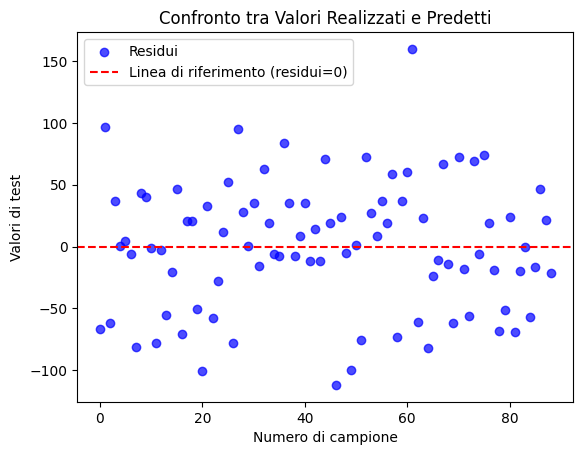

Scala: 37.00-310.00
Errore medio (RMSE): 19.03% punti sulla scala target


In [8]:
import matplotlib.pyplot as plt

plt.scatter(np.arange(len(y_test)), y_pred - y_test, alpha=0.7, c='blue', label='Residui')
plt.axhline(0, color='red', linestyle='--', label='Linea di riferimento (residui=0)')
plt.xlabel("Numero di campione")
plt.ylabel("Valori di test")
plt.title("Confronto tra Valori Realizzati e Predetti")
plt.legend()
plt.show()

print(f"Scala: {min(y_test):.2f}-{max(y_test):.2f}")
print(f"Errore medio (RMSE): {rmse / (max(y_test) - min(y_test)):.2%} punti sulla scala target")

In [14]:
from sklearn.linear_model import ElasticNet
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'alpha':    trial.suggest_float('alpha', 1e-4, 10.0, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter': 10000
    }
    model = ElasticNet(**params)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1000, show_progress_bar=True)
print(f"Miglior MSE (CV):    {-study.best_value:.4f}")
print(f"Migliori parametri: {study.best_params}")

Best trial: 732. Best value: -3140.55: 100%|██████████| 1000/1000 [00:27<00:00, 36.19it/s]

Miglior MSE (CV):    3140.5499
Migliori parametri: {'alpha': 0.004122943874627132, 'l1_ratio': 0.00034884666309654543}


# ElasticNet — Cheatsheet

## Cos'è
Regressione lineare **regolarizzata** che combina Ridge (L2) e Lasso (L1).
Aggiunge una penalità alla funzione di costo per evitare overfitting e
ridurre i coefficienti delle feature meno utili.

## Formula della funzione di costo
Loss = MSE + alpha * [l1_ratio * |coef| + (1 - l1_ratio) * coef²]
         ↑                 ↑ penalità L1 (Lasso)    ↑ penalità L2 (Ridge)
       errore         regolarizzazione totale

## Quando usarlo
✅ Dataset con relazione prevalentemente LINEARE tra feature e target
✅ Molte feature, alcune probabilmente irrilevanti (L1 le azzera)
✅ Feature correlate tra loro (L2 le gestisce senza eliminarle tutte)
✅ Dataset piccoli dove XGBoost/RF tendono all'overfitting
✅ Quando vuoi un modello interpretabile (leggi i coefficienti)
❌ Relazioni non lineari complesse → usa XGBoost/RF
❌ Dati tabellari enormi con interazioni → usa XGBoost

## Confronto con Ridge e Lasso
| Modello      | Penalità | Feature selection | Multicollinearità |
|--------------|----------|-------------------|-------------------|
| Ridge        | L2       | ❌ No (riduce)     | ✅ Gestisce bene   |
| Lasso        | L1       | ✅ Azzera feature  | ⚠️ Prende 1 di N  |
| ElasticNet   | L1 + L2  | ✅ Azzera alcune   | ✅ Gestisce bene   |

## Iperparametri chiave
- **alpha**: Forza totale della regolarizzazione.
  - alpha → 0: quasi nessuna regolarizzazione (OLS pura)
  - alpha → ∞: coefficienti tutti azzerati (underfitting)

- **l1_ratio**: Bilancia L1 e L2.
  - l1_ratio = 0.0  → Ridge pura  (nessuno azzeramento)
  - l1_ratio = 1.0  → Lasso pura  (azzeramento aggressivo)
  - l1_ratio = 0.5  → bilanciato 50/50

## Regola empirica di Optuna
alpha:    suggest_float('alpha', 1e-4, 10.0, log=True)
l1_ratio: suggest_float('l1_ratio', 0.0, 1.0)

## Note importanti
- Richiede SEMPRE StandardScaler (o simile) prima del fit
- Se l1_ratio trovato da Optuna → 0: il dataset preferisce Ridge
- Se l1_ratio trovato da Optuna → 1: il dataset preferisce Lasso
- Interpretabile: final_model.coef_ ti dice il peso di ogni feature